<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/news_popularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Requirements

In [1]:
!pip install pyspark
!pip install ucimlrepo

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pyspark
from pyspark.sql import SparkSession

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}\n")

Spark version: 4.0.2



In [148]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col as scol

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, UnivariateFeatureSelector
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics
from pyspark.sql import functions as F
import numpy as np

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

## Data Loading & Exploration

In [3]:
from ucimlrepo import fetch_ucirepo

online_news_popularity = fetch_ucirepo(id=332)
X = online_news_popularity.data.features
y = online_news_popularity.data.targets

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}")

Samples : 39644
Features: 58


In [4]:
print(f"Feature list: {X.columns}")

Feature list: Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_p

In [117]:
# Merge into one pandas frame
df = pd.concat([X, y], axis=1)

# Remove whitespace from column name
df.columns = df.columns.str.strip()
X.columns = X.columns.str.strip()
y.columns = y.columns.str.strip()

In [118]:
# Print some samples
df.sample(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
4263,13.0,350.0,0.585014,1.0,0.705607,9.0,2.0,1.0,0.0,4.837143,...,0.136364,1.0,-0.282813,-0.700000,-0.100,0.454545,0.136364,0.045455,0.136364,2000
30879,8.0,740.0,0.490437,1.0,0.664399,2.0,1.0,3.0,0.0,4.601351,...,0.062500,1.0,-0.317690,-0.600000,-0.125,0.600000,0.500000,0.100000,0.500000,642
26631,12.0,1966.0,0.404288,1.0,0.631103,1.0,1.0,2.0,1.0,4.362665,...,0.050000,1.0,-0.342580,-1.000000,-0.075,0.562626,-0.276768,0.062626,0.276768,907
13176,13.0,307.0,0.627986,1.0,0.760638,12.0,0.0,1.0,0.0,4.872964,...,0.100000,0.5,-0.200154,-0.250000,-0.125,0.000000,0.000000,0.500000,0.000000,1500
17287,10.0,431.0,0.562648,1.0,0.723320,8.0,2.0,1.0,0.0,4.512761,...,0.050000,0.8,-0.206771,-0.333333,-0.125,0.000000,0.000000,0.500000,0.000000,867


In [119]:
# Clean dataset (Remove Null & dupplicate rows)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Rows after clean: {len(df)}")

Missing values : 0
Duplicate rows : 0
Rows after clean: 39644


In [120]:
# Calculate the median of the target variable
THRESHOLD = int(df['shares'].median())
print(f"Median shares: {THRESHOLD}")

df["label"] = (df["shares"] > THRESHOLD).astype(int)
df.drop(columns=["shares"], inplace=True)

counts = df["label"].value_counts()
total  = len(df)
print(f"\nClass distribution:")
print(f"Popular(1): {counts.get(1,0)} ({counts.get(1,0)/total:.2%})")
print(f"Unpopular(0): {counts.get(0,0)} ({counts.get(0,0)/total:.2%})")

Median shares: 1400

Class distribution:
Popular(1): 19562 (49.34%)
Unpopular(0): 20082 (50.66%)


In [121]:
df.sample(5)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,label
33169,10.0,946.0,0.479321,1.0,0.677876,2.0,1.0,2.0,0.0,4.562368,...,0.100000,1.0,-0.307702,-1.00,-0.050000,0.6,0.7,0.1,0.7,0
22740,8.0,230.0,0.605634,1.0,0.765625,3.0,2.0,1.0,0.0,4.208696,...,0.400000,0.5,-0.203472,-0.40,-0.100000,0.0,0.0,0.5,0.0,0
2260,7.0,326.0,0.587662,1.0,0.674757,3.0,2.0,0.0,18.0,4.481595,...,0.062500,1.0,-0.316667,-0.60,-0.050000,0.0,0.0,0.5,0.0,0
11260,9.0,242.0,0.589212,1.0,0.738853,6.0,5.0,1.0,0.0,4.991736,...,0.100000,0.4,-0.191667,-0.25,-0.133333,1.0,0.6,0.5,0.6,0
31067,11.0,2147.0,0.339159,1.0,0.544974,13.0,4.0,3.0,1.0,4.309269,...,0.033333,0.7,-0.291559,-1.00,-0.050000,0.0,0.0,0.5,0.0,1


In [122]:
PALETTE = ["#C781A8", "#835496"]
COLORS  = ["#2E86AB", "#E84855", "#F6AE2D", "#2DC653"]

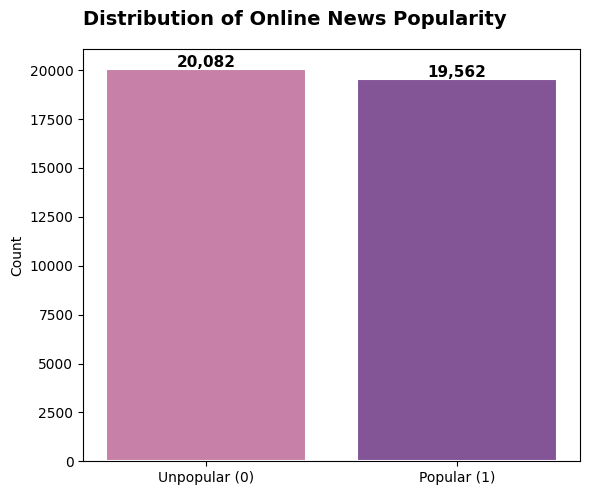

In [123]:
# Class Balance

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Distribution of Online News Popularity", fontsize=14, fontweight="bold")
counts_plot = df["label"].value_counts().sort_index()
bars = ax.bar(["Unpopular (0)", "Popular (1)"], counts_plot.values, color=PALETTE, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, counts_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Data Analysis

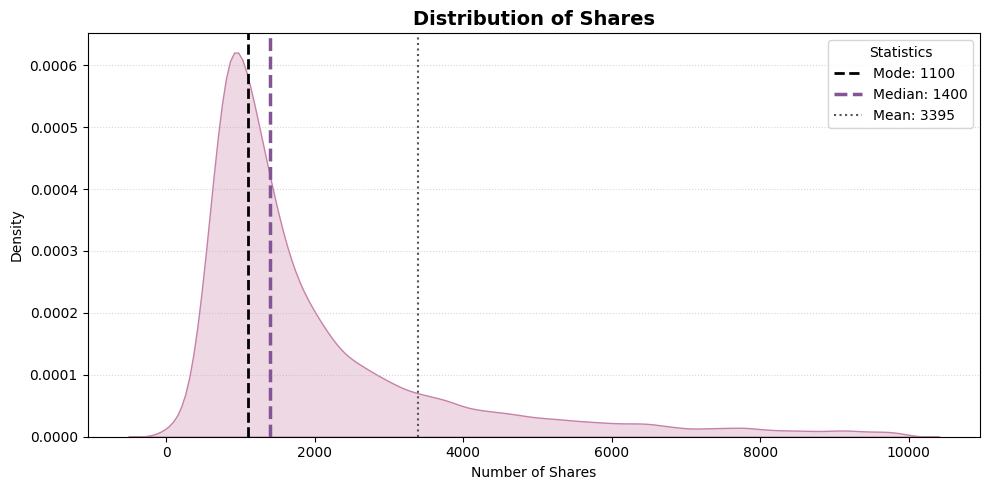

In [124]:
# Shares distribution

# Filter out for better presentation
filtered_y = y[y['shares'] < 10_000]['shares'].copy()

# Compute mean, median and mode
mean_val   = y['shares'].mean()
median_val = y['shares'].median()
mode_val   = y['shares'].mode()[0]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(filtered_y, color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)
ax.axvline(mode_val, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.0f}')
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
ax.axvline(mean_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.0f}')
ax.set_title("Distribution of Shares", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Shares"); ax.set_ylabel("Density")
ax.set_facecolor('white'); ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(title="Statistics")
plt.tight_layout()
plt.show()

In [125]:
print(f"Mean: {int(mean_val)}")
print(f"Median: {int(median_val)}")
print(f"Mode: {mode_val}")
print(f"Min: {y['shares'].min()}")
print(f"Max: {y['shares'].max()}")

Mean: 3395
Median: 1400
Mode: 1100
Min: 1
Max: 843300


The dataset is right skew (a few articles get thousends of shares while most get very few)

### Log Transformation -> For outlier analysis

Taking the log "squashes" the extreme values, making the distribution more normal and preventing the outlier threshold from being pushed too high by a few massive viral hits.

In [126]:
# Outlier Analysis
log_shares = np.log1p(y['shares'])

Q1 = log_shares.quantile(0.25)
Q3 = log_shares.quantile(0.75)
IQR = Q3 - Q1
upper_bound_log = Q3 + 1.5 * IQR

upper_bound = int(np.expm1(upper_bound_log))

# Convert Q3 back to original scale for printing
Q3_original = int(np.expm1(Q3))
extreme = (y['shares'] > upper_bound).sum()

print(f"\n75% of articles have fewer shares than {Q3_original}")
print(f"IQR-based outlier threshold: {upper_bound}")
print(f"Outliers above threshold: {extreme} ({extreme/len(y['shares']):.2%})")


75% of articles have fewer shares than 2800
IQR-based outlier threshold: 14247
Outliers above threshold: 1368 (3.45%)


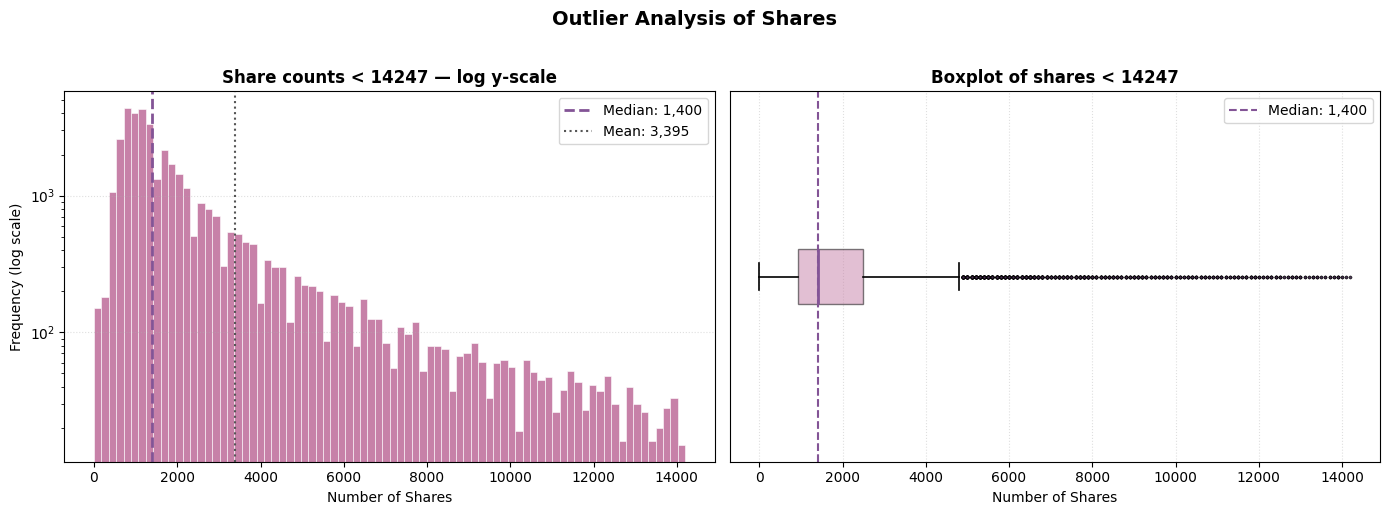

In [127]:
# plot
shares_temp = y['shares'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with log y-scale
data_hist = shares_temp[shares_temp < upper_bound]
axes[0].hist(data_hist, bins=80, color="#C781A8", edgecolor='white', linewidth=0.4)
axes[0].set_yscale('log')                          # log y-axis reveals the tail shape
axes[0].axvline(shares_temp.median(), color='#835496', linestyle='--', linewidth=2, label=f'Median: {shares_temp.median():,.0f}')
axes[0].axvline(shares_temp.mean(), color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {shares_temp.mean():,.0f}')
axes[0].set_title(f"Share counts < {upper_bound} — log y-scale", fontweight='bold')
axes[0].set_xlabel("Number of Shares")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].legend()
axes[0].grid(axis='y', linestyle=':', alpha=0.4)

# Right: horizontal boxplot
data_box = shares_temp[shares_temp < upper_bound]
axes[1].boxplot(data_box, vert=False,              # horizontal is easier to read
                patch_artist=True,
                boxprops=dict(facecolor="#C781A8", alpha=0.5),
                medianprops=dict(color='#835496', linewidth=2),
                flierprops=dict(marker='.', markerfacecolor='#835496', alpha=0.2, markersize=3),  # smaller outlier dots
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
axes[1].set_title(f"Boxplot of shares < {upper_bound}", fontweight='bold')
axes[1].set_xlabel("Number of Shares")
axes[1].set_yticks([])                             # removes the "1" tick
axes[1].axvline(shares_temp.median(), color='#835496', linestyle='--', linewidth=1.5, label=f'Median: {shares_temp.median():,.0f}')
axes[1].legend()
axes[1].grid(axis='x', linestyle=':', alpha=0.4)

plt.suptitle("Outlier Analysis of Shares", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pearson correlation heatmap (top 20 features)

### Pearson Correlation (r)

Pearson Correlation is a way to calculate the pairwise correlation between a single target (label) and a set of other variables.

Mathematically, it measures the linear relationship between two variables, $X$ (feature) and $Y$ (label), using this formula:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$$

- Numerator (Covariance): It checks if $X$ and $Y$ move together. If $X$ is above its mean when $Y$ is also above its mean, the correlation goes up.

- Denominator (Normalization): It divides by the product of the standard deviations. This "squashes" the result into a range between -1.0 and +1.0.

- The results:

  - +1.0: Perfect positive linear relationship.

  - 1.0: Perfect negative linear relationship.

  - 0: No linear relationship at all.

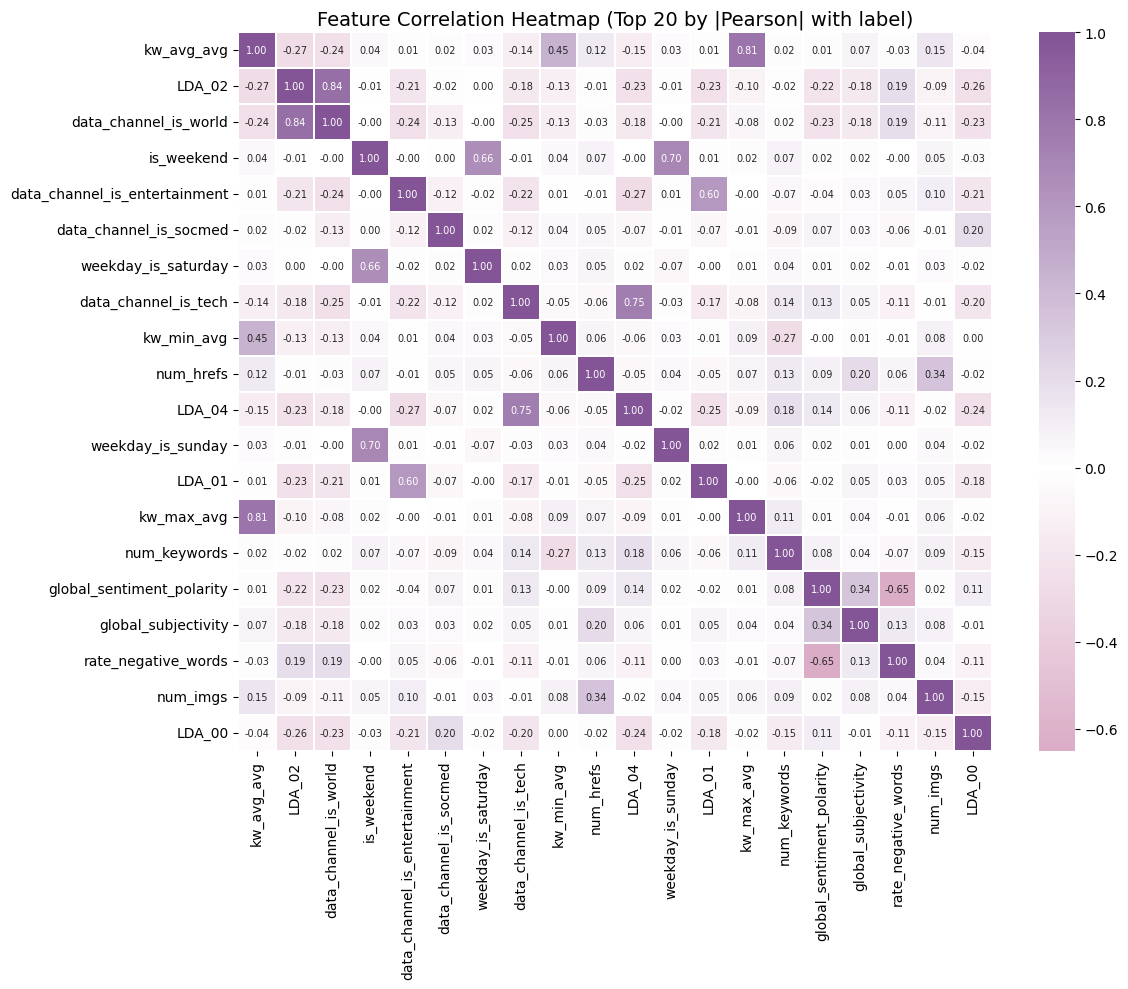

In [128]:
feature_list = [c for c in X.columns]
label_corr   = df[feature_list].corrwith(df["label"]).abs().nlargest(20)
top20_features = label_corr.index.tolist()

colors_cmap = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors_cmap)

plt.figure(figsize=(12, 10))
sub_corr = df[top20_features].corr()
sns.heatmap(sub_corr, cmap=cmap, center=0, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap (Top 20 by |Pearson| with label)", fontsize=14)
plt.tight_layout()
plt.show()

### Relative mean difference between popular vs unpopular articles

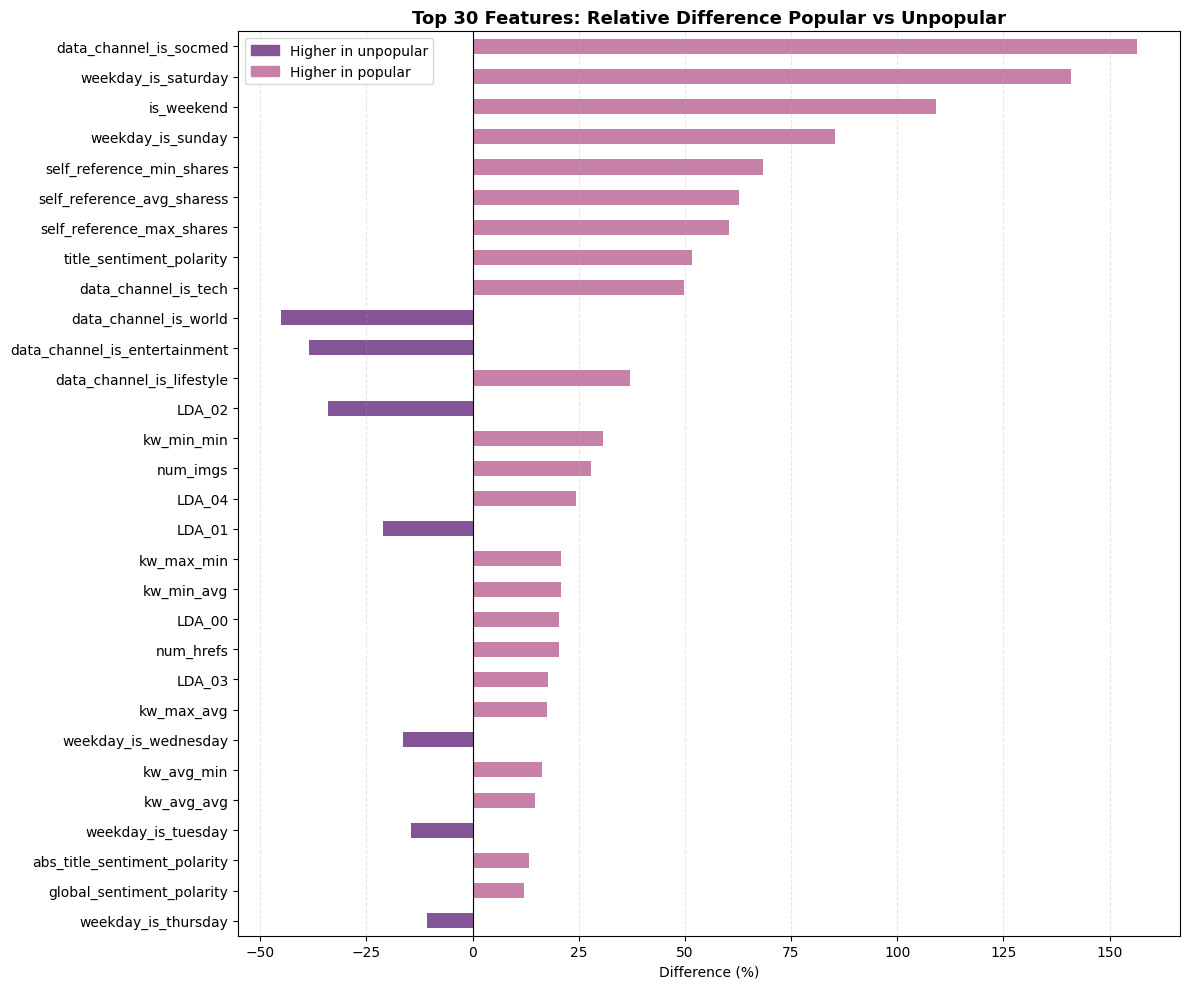

In [129]:
unpopular_mean = df[df['label'] == 0].mean(numeric_only=True)
popular_mean   = df[df['label'] == 1].mean(numeric_only=True)

class_diff = pd.DataFrame({'Mean_Unpopular': unpopular_mean,
                            'Mean_Popular':   popular_mean})
class_diff['Diff (%)'] = (
    (class_diff['Mean_Popular'] - class_diff['Mean_Unpopular'])
    / class_diff['Mean_Unpopular'].replace(0, np.nan)
) * 100
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()
class_diff = class_diff.drop('label', errors='ignore')

top30_diff  = class_diff.sort_values('Abs_Diff', ascending=False).head(30)
colors_diff = np.where(top30_diff['Diff (%)'] > 0, PALETTE[0], PALETTE[1])

plt.figure(figsize=(12, 10))
top30_diff['Diff (%)'].plot(kind='barh', color=colors_diff)
plt.title('Top 30 Features: Relative Difference Popular vs Unpopular',
          fontsize=13, fontweight='bold')
plt.xlabel('Difference (%)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()
purple_patch = mpatches.Patch(color='#835496', label='Higher in unpopular')
pink_patch   = mpatches.Patch(color='#C781A8', label='Higher in popular')
plt.legend(handles=[purple_patch, pink_patch])
plt.tight_layout()
plt.show()

## Feature Engineering

### Why this matters
Raw features fed into the original model had two problems:
1. **Skewed distributions**: features like `n_tokens_content`, `self_reference_avg_shares`, and keyword
   counts span several orders of magnitude. Log-transforming them compresses the tail, stabilises
   variance, and is especially important for Logistic Regression which assumes roughly Gaussian inputs.
2. **Missing interaction signals**: the ratio of links to content length, or the combined keyword
   strength, are meaningful signals that neither feature alone captures. We add 6 engineered features.

In [130]:
# Push to Spark
sdf = spark.createDataFrame(df)
sdf.printSchema()
print(f"Total rows in Spark df: {sdf.count()}")

root
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: double (nullable = true)
 |-- kw_max_min: double (nullable = true)
 |-- kw_avg_min: double (nullable = true)
 |-- kw_min_max: double (nullab

### ANOVA

35% sample is enough to get stable AUC estimates while keeping sweep fast.

Split computed ONCE so every k candidate sees the exact same train/val data —
without this, AUC differences between k values could reflect split randomness rather than feature quality.

In [138]:
# Pearson pre-filter (|r| > 0.01)

corr_with_label = (
    df.drop(columns=["label"])
    .corrwith(df["label"]).abs()
    .sort_values(ascending=False)
)

pre_filtered = corr_with_label.index.tolist()

# feature_cols = [c for c in sdf.columns if c != "label"]
# # Remove statistically insignificant correlations
# pre_filtered = corr_with_label[corr_with_label > 0.01].index.tolist()
# print(f"Pre-filter (|corr| > 0.01): {len(feature_cols)} → {len(pre_filtered)} features")

In [140]:
#ANOVA F-test sweep (k = 20, 30, 40, 48)

corr_with_label = (
    df.drop(columns=["label"])
    .corrwith(df["label"]).abs()
    .sort_values(ascending=False)
)

pre_filtered = corr_with_label.index.tolist()

# Assembler & Scaler : Combines and normalizes numerical features
assembler = VectorAssembler(inputCols=pre_filtered, outputCol="raw_features", handleInvalid="skip")
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withMean=True, withStd=True)

# Sample for sweep
sdf_sample  = sdf.sample(fraction=0.35, seed=42)
train_s, val_s = sdf_sample.randomSplit([0.8, 0.2], seed=42)
print(f"Sweep sample — train: {train_s.count():,}   val: {val_s.count():,}")

k_candidates = [10, 20, 30, 40, 48]
auc_scores = {}
best_k = 0
best_auc = 0.0

print("\nANOVA feature selection sweep (UnivariateFeatureSelector + LR AUC):\n")
print(f"  {'k':>4}  {'AUC':>8}  {'improvement':>10}  {'Selected?':>10}")
print(f"  {'-'*4}  {'-'*8}  {'-'*10}  {'-'*10}")

prev_auc = None
for k in k_candidates:
    selector_sweep = UnivariateFeatureSelector(
        featuresCol="scaled_features",
        outputCol="sel_features",
        labelCol="label",
        selectionMode="numTopFeatures"
    ).setFeatureType("continuous") \
     .setLabelType("categorical")  \
     .setSelectionThreshold(k)

    lr_tmp = LogisticRegression(
        featuresCol="sel_features", labelCol="label",
        maxIter=20, regParam=0.01
    )

    pipe_tmp  = Pipeline(stages=[assembler, scaler, selector_sweep, lr_tmp])
    model_tmp = pipe_tmp.fit(train_s)
    preds_tmp = model_tmp.transform(val_s)

    auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(preds_tmp)

    auc_scores[k] = auc

    delta = f"{auc - prev_auc:+.4f}" if prev_auc is not None else "baseline"
    is_best = auc > (best_auc + 0.0001)
    selected = "YES" if is_best else "NO"
    print(f"{k:>4}  {auc:.4f}    {delta:>10}  {selected}")

    if is_best:
        best_auc, best_k = auc, k
    prev_auc = auc

print(f"\nBest k = {best_k} (AUC = {best_auc:.4f})")

Sweep sample — train: 11,228   val: 2,693

ANOVA feature selection sweep (UnivariateFeatureSelector + LR AUC):

     k       AUC  improvement   Selected?
  ----  --------  ----------  ----------
    10  0.6779      baseline  YES
    20  0.6792       +0.0013  YES
    30  0.6838       +0.0046  YES
    40  0.6938       +0.0100  YES
    50  0.6930       -0.0007  
    58  0.6940       +0.0010  YES

Best k = 58 (AUC = 0.6940)


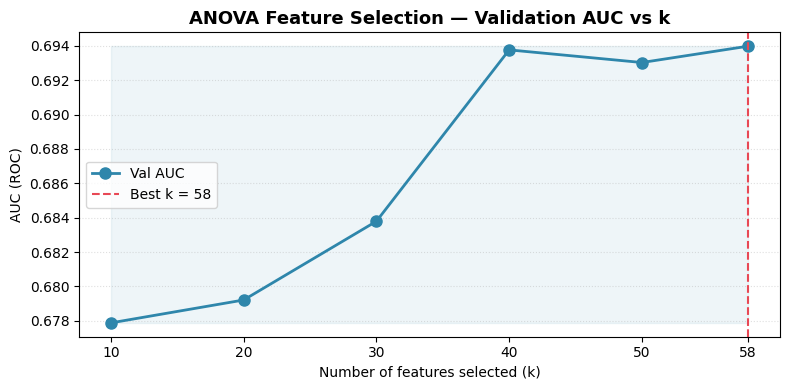

In [141]:
# Plot AUC vs k
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(list(auc_scores.keys()), list(auc_scores.values()), marker="o", color="#2E86AB", linewidth=2, markersize=8, label="Val AUC")

# Shade the region between min and max AUC to show how flat the curve is
auc_vals = list(auc_scores.values())
ax.fill_between(list(auc_scores.keys()), min(auc_vals), max(auc_vals), alpha=0.08, color="#2E86AB")

# Mark the best k with a vertical line and annotation
ax.axvline(best_k, color="#E84855", linestyle="--", linewidth=1.5, label=f"Best k = {best_k}")

ax.set_title("ANOVA Feature Selection — Validation AUC vs k", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of features selected (k)")
ax.set_ylabel("AUC (ROC)")
ax.set_xticks(k_candidates)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [142]:
# Final selector for all training pipelines
selector_final = UnivariateFeatureSelector(
    featuresCol="scaled_features",
    outputCol="features",
    labelCol="label",
    selectionMode="numTopFeatures"
).setFeatureType("continuous") \
 .setLabelType("categorical")  \
 .setSelectionThreshold(best_k)

## Rolling-Window Time-Series Split

Unlike a standard cross-validation where data is shuffled randomly, this method respects the temporal order.

In [144]:
# Assign row numbers in chronological order
sdf_ordered = (sdf.coalesce(1).withColumn("row_num", row_number().over(Window.orderBy(scol(sdf.columns[1]).desc())) - 1))

# Cache because we will filter this dataframe many times in the fold loop
sdf_ordered.cache()
total_rows = sdf_ordered.count()

# Window parameters
total_rows = sdf_ordered.count()
L = 3_000
num_folds = 6  # desired number of folds

# Compute W automatically to have zero waste
# total_rows = W + L + (num_folds - 1) * L
# → W = total_rows - num_folds * L
W = total_rows - num_folds * L  # ← auto-computed, no waste by definition

TRAIN_FRAC   = 0.70
TRAIN_SIZE   = int(W * TRAIN_FRAC)
EVAL_SIZE    = W - TRAIN_SIZE
total_window = W + L

# Verify
num_folds_check = (total_rows - total_window) // L + 1
waste           = (total_rows - total_window) % L

print(f"\nWindow parameters:")
print(f"W (train + eval) : {W}")
print(f"W Train : {TRAIN_SIZE} -> ({TRAIN_FRAC:.0%} of W)")
print(f"W Eval  : {EVAL_SIZE} -> ({1-TRAIN_FRAC:.0%} of W)")
print(f"L (test / step)  : {L}")
print(f"Total window     : {total_window} -> (W + L)")
print(f"Number of folds  : {num_folds_check}")
print(f"Number of waste  : {waste}")  # → always 0

# Build fold splits
splits = []

print(f"\n{'─'*85}")
print(f"  {'Fold':>4}  {'Train start':>11}  {'Train end':>9}  "
      f"{'Eval start':>10}  {'Eval end':>8}  "
      f"{'Test start':>10}  {'Test end':>8}  "
      f"{'n_train':>8}  {'n_eval':>7}  {'n_test':>7}")
print(f"{'─'*85}")

for i in range(num_folds):
    # Starting row index for this fold
    start = i * L

    # Train zone: [start, start + TRAIN_SIZE)
    tr_start = start
    tr_end   = start + TRAIN_SIZE - 1

    # Eval zone: [start + TRAIN_SIZE, start + W)
    ev_start = tr_end + 1
    ev_end   = start + W - 1

    # Test zone: [start + W, start + W + L)
    te_start = start + W
    te_end   = min(start + W + L - 1, total_rows - 1)  # boundary guard

    # Filter Spark dataframe for each zone
    train_fold = sdf_ordered.filter(
        (scol("row_num") >= tr_start) & (scol("row_num") <= tr_end)
    )
    eval_fold  = sdf_ordered.filter(
        (scol("row_num") >= ev_start) & (scol("row_num") <= ev_end)
    )
    test_fold  = sdf_ordered.filter(
        (scol("row_num") >= te_start) & (scol("row_num") <= te_end)
    )

    splits.append((train_fold, eval_fold, test_fold))

    # Count rows for verification
    n_train = train_fold.count()
    n_eval  = eval_fold.count()
    n_test  = test_fold.count()

    print(f"  {i+1:>4}  {tr_start:>11,}  {tr_end:>9,}  "
          f"{ev_start:>10,}  {ev_end:>8,}  "
          f"{te_start:>10,}  {te_end:>8,}  "
          f"{n_train:>8,}  {n_eval:>7,}  {n_test:>7,}")

print(f"{'─'*85}")
N_SPLITS = len(splits)
print(f"\nTotal folds created: {N_SPLITS}")


Window parameters:
W (train + eval) : 21644
W Train : 15150 -> (70% of W)
W Eval  : 6494 -> (30% of W)
L (test / step)  : 3000
Total window     : 24644 -> (W + L)
Number of folds  : 6
Number of waste  : 0

─────────────────────────────────────────────────────────────────────────────────────
  Fold  Train start  Train end  Eval start  Eval end  Test start  Test end   n_train   n_eval   n_test
─────────────────────────────────────────────────────────────────────────────────────
     1            0     15,149      15,150    21,643      21,644    24,643    15,150    6,494    3,000
     2        3,000     18,149      18,150    24,643      24,644    27,643    15,150    6,494    3,000
     3        6,000     21,149      21,150    27,643      27,644    30,643    15,150    6,494    3,000
     4        9,000     24,149      24,150    30,643      30,644    33,643    15,150    6,494    3,000
     5       12,000     27,149      27,150    33,643      33,644    36,643    15,150    6,494    3,000
   

In [145]:
# Class balance check per fold
print("\nClass balance per fold (test set):")
print(f"  {'Fold':>4}  {'Class 0':>8}  {'Class 1':>8}  {'% Popular':>10}  {'Balanced?':>10}")
print(f"  {'-'*4}  {'-'*8}  {'-'*8}  {'-'*10}  {'-'*10}")

for i, (_, _, te) in enumerate(splits):
    counts   = te.groupBy("label").count().collect()
    count_0  = next((r["count"] for r in counts if r["label"] == 0), 0)
    count_1  = next((r["count"] for r in counts if r["label"] == 1), 0)
    pct_pop  = count_1 / (count_0 + count_1) * 100
    balanced = "✔" if 40 <= pct_pop <= 60 else "skewed"
    print(f"  {i+1:>4}  {count_0:>8,}  {count_1:>8,}  {pct_pop:>9.1f}%  {balanced:>10}")


Class balance per fold (test set):
  Fold   Class 0   Class 1   % Popular   Balanced?
  ----  --------  --------  ----------  ----------
     1     1,580     1,420       47.3%           ✔
     2     1,531     1,469       49.0%           ✔
     3     1,509     1,491       49.7%           ✔
     4     1,500     1,500       50.0%           ✔
     5     1,463     1,537       51.2%           ✔
     6     1,518     1,482       49.4%           ✔


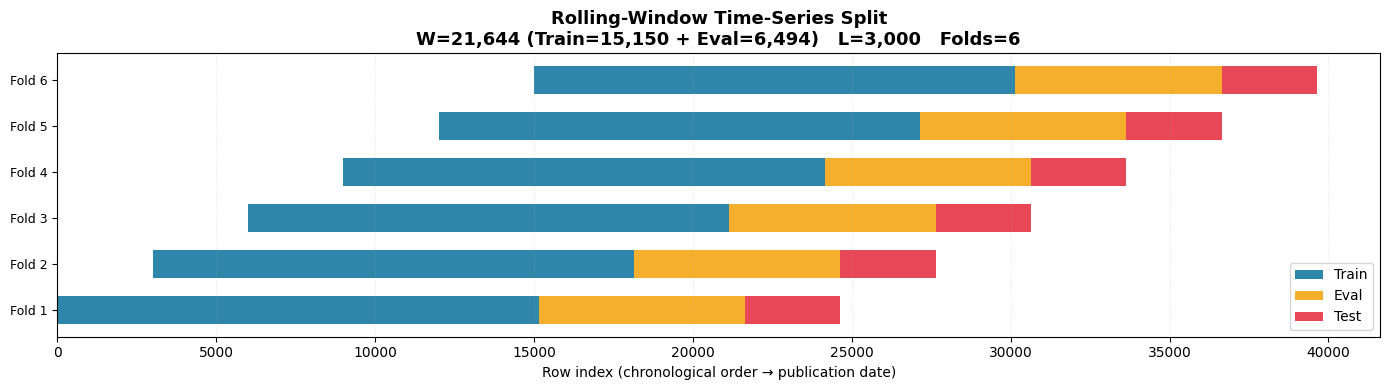

In [146]:
# Visualise the splits
fig, ax = plt.subplots(figsize=(14, max(4, N_SPLITS * 0.6)))

for i, (tr, ev, te) in enumerate(splits):
    tr_s = tr.agg(F.min("row_num")).collect()[0][0]
    tr_e = tr.agg(F.max("row_num")).collect()[0][0]
    ev_s = ev.agg(F.min("row_num")).collect()[0][0]
    ev_e = ev.agg(F.max("row_num")).collect()[0][0]
    te_s = te.agg(F.min("row_num")).collect()[0][0]
    te_e = te.agg(F.max("row_num")).collect()[0][0]

    ax.barh(i, tr_e - tr_s, left=tr_s, height=0.6,
            color="#2E86AB", label="Train"  if i == 0 else "")
    ax.barh(i, ev_e - ev_s, left=ev_s, height=0.6,
            color="#F6AE2D", label="Eval"   if i == 0 else "")
    ax.barh(i, te_e - te_s, left=te_s, height=0.6,
            color="#E84855", label="Test"   if i == 0 else "")

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)], fontsize=9)
ax.set_xlabel("Row index (chronological order → publication date)")
ax.set_title(
    f"Rolling-Window Time-Series Split\n"
    f"W={W:,} (Train={TRAIN_SIZE:,} + Eval={EVAL_SIZE:,})   "
    f"L={L:,}   Folds={N_SPLITS}",
    fontsize=13, fontweight='bold'
)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

## Model Definitions & Grid Search

In [147]:
# Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees,            [50, 100])
    .addGrid(rf.maxDepth,            [5, 10])
    .addGrid(rf.minInstancesPerNode, [1, 5])
    .build()
)

# Gradient Boosted Tree
gbt = GBTClassifier(featuresCol="features", labelCol="label", seed=42, maxIter=50)
gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)

# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0,  0.5])
    .build()
)

model_configs = [
    ("Random Forest", rf, rf_grid),
    ("Gradient Boosted Tree", gbt, gbt_grid),
    ("Logistic Regression", lr, lr_grid),
]
print("Model configs ready.")
for name, _, grid in model_configs:
    print(f"  {name}: {len(grid)} hyperparameter combinations")

Model configs ready.
  Random Forest: 8 hyperparameter combinations
  Gradient Boosted Tree: 4 hyperparameter combinations
  Logistic Regression: 6 hyperparameter combinations


## Helper Functions

In [152]:
# ─────────────────────────────────────────────
# HELPER 1: Compute Metrics
# ─────────────────────────────────────────────
def compute_metrics(predictions, threshold=0.5):
    """
    Computes Accuracy, F1, Precision, Recall, and AUC
    from a Spark predictions DataFrame.

    Args:
        predictions : Spark DataFrame with 'probability' and 'label' columns
        threshold   : classification threshold (default 0.5)

    Returns:
        dict with accuracy, f1, precision, recall, auc
    """
    # Apply threshold to probability column
    extract_prob = F.udf(lambda v: float(v[1]), "double")
    preds = predictions.withColumn("prob_positive", extract_prob(F.col("probability")))
    preds = preds.withColumn(
        "prediction",
        (F.col("prob_positive") >= threshold).cast("double")
    )

    # AUC via BinaryClassificationEvaluator
    auc_evaluator = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    auc = auc_evaluator.evaluate(predictions)

    # Accuracy, F1, Precision, Recall via MulticlassMetrics
    preds_rdd = preds.select("prediction", "label") \
                     .rdd.map(lambda r: (r.prediction, float(r.label)))

    multi_metrics = MulticlassMetrics(preds_rdd)

    accuracy  = multi_metrics.accuracy
    f1        = multi_metrics.fMeasure(1.0, beta=1.0)
    precision = multi_metrics.precision(1.0)
    recall    = multi_metrics.recall(1.0)

    return {
        "accuracy"  : accuracy,
        "f1"        : f1,
        "precision" : precision,
        "recall"    : recall,
        "auc"       : auc,
        "threshold" : threshold
    }


# ─────────────────────────────────────────────
# HELPER 2: Find Best Threshold on Eval Set
# ─────────────────────────────────────────────
def find_best_threshold(model, eval_sdf, thresholds=None):
    """
    Tunes classification threshold on eval set by maximizing F1.

    Args:
        model      : fitted PipelineModel
        eval_sdf   : eval Spark DataFrame
        thresholds : list of thresholds to try (default: 0.1 to 0.9)

    Returns:
        best_threshold (float), best_f1 (float)
    """
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05).tolist()

    predictions = model.transform(eval_sdf)
    extract_prob = F.udf(lambda v: float(v[1]), "double")
    predictions = predictions.withColumn("prob_positive", extract_prob(F.col("probability")))
    predictions.cache()

    best_threshold, best_f1 = 0.5, 0.0

    for t in thresholds:
        preds = predictions.withColumn(
            "prediction",
            (F.col("prob_positive") >= t).cast("double")
        )
        preds_rdd = preds.select("prediction", "label") \
                         .rdd.map(lambda r: (r.prediction, float(r.label)))

        try:
            metrics = MulticlassMetrics(preds_rdd)
            f1 = metrics.fMeasure(1.0, beta=1.0)
            if f1 > best_f1:
                best_f1        = f1
                best_threshold = t
        except Exception:
            continue

    predictions.unpersist()
    return best_threshold, best_f1


# ─────────────────────────────────────────────
# HELPER 3: Train and Evaluate One Model
# ─────────────────────────────────────────────
def train_and_evaluate(name, estimator, param_grid,
                       train_sdf, eval_sdf, test_sdf,
                       pre_stages, evaluator_auc):
    """
    Full 3-way split workflow per fold:
      1. CrossValidator tunes hyperparams on train_sdf (3-fold CV)
      2. Best pipeline refit on train + eval (full window W)
      3. Threshold tuned on eval_sdf only (no test leakage)
      4. Final metrics on test_sdf with optimal threshold

    Args:
        name          : model name string
        estimator     : Spark ML estimator (rf, gbt, lr)
        param_grid    : list of ParamMaps
        train_sdf     : training Spark DataFrame
        eval_sdf      : evaluation Spark DataFrame
        test_sdf      : test Spark DataFrame
        pre_stages    : list of pipeline stages before estimator
        evaluator_auc : BinaryClassificationEvaluator instance

    Returns:
        metrics (dict), final_model (PipelineModel)
    """
    pipeline = Pipeline(stages=pre_stages + [estimator])

    # Step 1: Hyperparameter search on train only
    cv = CrossValidator(
        estimator        = pipeline,
        estimatorParamMaps = param_grid,
        evaluator        = evaluator_auc,
        numFolds         = 3,
        seed             = 42,
        parallelism      = 2
    )
    print(f"  [{name}] Fitting CV ...", end=" ", flush=True)
    cv_model = cv.fit(train_sdf)
    print("done.")

    # Step 2: Refit best pipeline on full window (train + eval)
    best_params  = cv_model.bestModel.stages[-1].extractParamMap()
    full_W       = train_sdf.union(eval_sdf)
    final_model  = pipeline.fit(full_W)

    # Step 3: Tune threshold on eval set only
    best_threshold, val_f1 = find_best_threshold(final_model, eval_sdf)
    print(f"  [{name}] Best threshold={best_threshold:.2f}  val_F1={val_f1:.4f}")

    # Step 4: Evaluate on test set
    test_preds = final_model.transform(test_sdf)
    metrics    = compute_metrics(test_preds, threshold=best_threshold)

    print(f"  [{name}] ACC={metrics['accuracy']:.4f}  "
          f"F1={metrics['f1']:.4f}  "
          f"P={metrics['precision']:.4f}  "
          f"R={metrics['recall']:.4f}  "
          f"AUC={metrics['auc']:.4f}")

    return metrics, final_model

In [ ]:
# ─────────────────────────────────────────────
# MAIN: Run All Models Over Rolling Window
# ─────────────────────────────────────────────
def run_rolling_window(model_configs, splits, pre_stages, evaluator_auc):
    """
    Trains each model on every fold and aggregates results.

    Args:
        model_configs  : list of (name, estimator, param_grid)
        splits         : list of (train_sdf, eval_sdf, test_sdf) per fold
        pre_stages     : preprocessing pipeline stages
        evaluator_auc  : BinaryClassificationEvaluator instance

    Returns:
        all_results (dict): {model_name: [metrics_fold1, metrics_fold2, ...]}
    """
    all_results = {name: [] for name, _, _ in model_configs}

    for fold_idx, (train_sdf, eval_sdf, test_sdf) in enumerate(splits):
        print(f"\n{'═'*60}")
        print(f"  FOLD {fold_idx + 1} / {len(splits)}")
        print(f"{'═'*60}")

        for name, estimator, param_grid in model_configs:
            print(f"\n  ── {name} ──")
            try:
                metrics, _ = train_and_evaluate(
                    name        = name,
                    estimator   = estimator,
                    param_grid  = param_grid,
                    train_sdf   = train_sdf,
                    eval_sdf    = eval_sdf,
                    test_sdf    = test_sdf,
                    pre_stages  = pre_stages,
                    evaluator_auc = evaluator_auc
                )
                metrics["fold"] = fold_idx + 1
                all_results[name].append(metrics)

            except Exception as e:
                print(f"  [{name}] ERROR on fold {fold_idx+1}: {e}")
                continue

    # Summary across folds
    print(f"\n{'═'*60}")
    print("  FINAL SUMMARY (mean ± std across folds)")
    print(f"{'═'*60}")
    print(f"  {'Model':<25} {'AUC':>7} {'F1':>7} {'ACC':>7} {'P':>7} {'R':>7}")
    print(f"  {'─'*55}")

    for name, fold_metrics in all_results.items():
        if not fold_metrics:
            continue
        for metric in ["auc", "f1", "accuracy", "precision", "recall"]:
            vals = [m[metric] for m in fold_metrics]

        auc  = np.mean([m["auc"]       for m in fold_metrics])
        f1   = np.mean([m["f1"]        for m in fold_metrics])
        acc  = np.mean([m["accuracy"]  for m in fold_metrics])
        prec = np.mean([m["precision"] for m in fold_metrics])
        rec  = np.mean([m["recall"]    for m in fold_metrics])

        print(f"  {name:<25} {auc:>7.4f} {f1:>7.4f} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f}")

    return all_results